# 02_baseline_tft_synthetic.ipynb
**Goal:** Learn Temporal Fusion Transformer (TFT) on the same synthetic PV + weather toy dataset used for the LSTM notebook.  
This notebook mimics the LSTM notebook structure: synthetic data → preprocessing → dataset → model → training → evaluation → interpretability.


## Installation and Imports

In [2]:


# Core imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# PyTorch Lightning & PyTorch Forecasting
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

import pytorch_forecasting
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# Repro
RSEED = 42
np.random.seed(RSEED)
torch.manual_seed(RSEED)

print("pytorch-forecasting version:", pytorch_forecasting.__version__)
print("pytorch lightning version:", pl.__version__)
print("torch version:", torch.__version__)


pytorch-forecasting version: 1.4.0
pytorch lightning version: 2.5.5
torch version: 2.7.1


### 2 - Synthetic dataset as same as the lstm test notebook
we created the same toy dataset: diurnal + seasonal + cloud bursts + temperature.

In [3]:
def make_synthetic_pv(start_date="2024-01-01", hours=24*90, freq_minutes=15):
    """
    Create synthetic PV + weather time series.
    - hours: number of hours to simulate (default: 90 days -> 2160 hours)
    - freq_minutes: 15 -> 4 samples per hour
    """
    periods = int(hours * 60 / freq_minutes)
    idx = pd.date_range(start=start_date, periods=periods, freq=f"{freq_minutes}min")
    df = pd.DataFrame(index=idx)

    # Time features
    t = np.arange(periods)
    day_of_year = df.index.dayofyear.values
    hour = df.index.hour + df.index.minute / 60.0
    
    # Diurnal irradiance-like signal (sunrise-sunset)
    diurnal = np.clip(np.sin((hour - 6) / 24 * 2 * np.pi), 0, None)  # shifted sine, nights = 0
    # Seasonal amplitude (over the whole period)
    seasonal = 0.5 + 0.5 * np.sin(2*np.pi * (day_of_year / 365.0))
    # Cloud events: occasional drops (random)
    clouds = (np.random.rand(periods) * 0.6) * (np.random.rand(periods) < 0.05).astype(float)
    clouds = np.convolve(clouds, np.ones(12)/12, mode='same')  # smooth bursts

    # Weather channels
    temp = 10 + 10 * seasonal + 3*np.sin(2*np.pi * (hour/24)) + np.random.randn(periods)*0.5
    cloud_index = np.clip(0.2 + 0.7*clouds + 0.2*np.random.rand(periods), 0, 1)

    # PV raw (normalized 0..1), then scale to capacity (e.g., 1.0)
    pv_norm = diurnal * seasonal * (1 - cloud_index) + np.random.randn(periods)*0.01
    pv_norm = np.clip(pv_norm, 0, None)

    df['pv'] = pv_norm
    df['temp'] = temp
    df['cloud_index'] = cloud_index
    # Add a simple PVLib-like ideal clear-sky feature (proxy)
    df['ghi_clear'] = diurnal * seasonal

    return df

# create toy dataset
df = make_synthetic_pv(hours=24*40, freq_minutes=15)  # ~40 days so runs fast
df.head(), df.shape


(                           pv       temp  cloud_index  ghi_clear
 2024-01-01 00:00:00  0.000000  15.110731     0.361861        0.0
 2024-01-01 00:15:00  0.000000  15.643500     0.405501        0.0
 2024-01-01 00:30:00  0.000000  15.295005     0.330560        0.0
 2024-01-01 00:45:00  0.004052  16.865322     0.260166        0.0
 2024-01-01 01:00:00  0.000000  15.952559     0.291156        0.0,
 (3840, 4))

### 3 - VIsulization
Same as before, sanity check visualizations

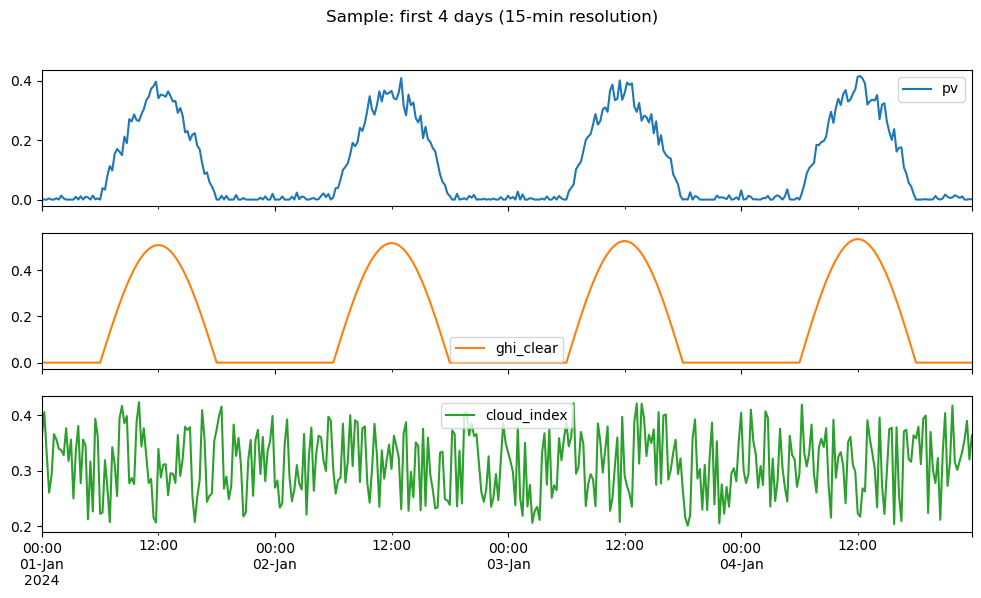

In [4]:
df[['pv','ghi_clear','cloud_index']].iloc[:4*24*4].plot(subplots=True, figsize=(12,6))
plt.suptitle("Sample: first 4 days (15-min resolution)")
plt.show()


### 4 — Prepare DataFrame for TimeSeriesDataSet
`pytorch-forecasting` expects a long DataFrame with:
- `time_idx`: integer index of time (monotonic)
- `group_id` (or group ids): identifies time series (we use a single series "site_1")
- `target`: value we want to predict ('pv')
- time-varying known reals: covariates known into the future (e.g. scheduled or forecast inputs)
- time-varying unknown reals: variables only known in history (e.g., measured PV)


In [5]:
# Build a working dataframe for TimeSeriesDataSet
df2 = df.copy().reset_index().rename(columns={'index':'timestamp'})
df2['time_idx'] = np.arange(len(df2))  # integer time index
df2['series'] = "site_1"               # group id for single series example

# For demonstration: treat ghi_clear as *known* future covariate (proxy for clear-sky forecast).
# pv, temp, cloud_index are unknown reals (only observed historically).
df2 = df2[['time_idx','timestamp','series','pv','temp','cloud_index','ghi_clear']]

# Quick train/val/test split by time index
n = len(df2)
train_end = int(0.8*n)
val_end = int(0.9*n)

df_train = df2.iloc[:train_end].copy()
df_val   = df2.iloc[train_end:val_end].copy()
df_test  = df2.iloc[val_end:].copy()

print(df_train.shape, df_val.shape, df_test.shape)


(3072, 7) (384, 7) (384, 7)


### 5 — TimeSeriesDataSet (encoder/decoder lengths)
- `max_encoder_length` = how far back the model sees (we use 72h = 288 steps as before).
- `max_prediction_length` = how far ahead we predict. For this toy run we use a short horizon so training is quick (e.g., 4 hours = 16 steps). Later you can scale.
- Use `GroupNormalizer` to normalize targets per series (helpful if multiple sites later).


In [6]:
# chosen lengths for quick prototype
max_encoder_length = 288   # 72 hours at 15-min resolution
max_prediction_length = 16 # 4 hours ahead (prototype)

training = TimeSeriesDataSet(
    df_train,
    time_idx="time_idx",
    target="pv",
    group_ids=["series"],
    min_encoder_length=max_encoder_length//2,  # allow variable length
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_reals=[],
    time_varying_known_reals=["time_idx", "ghi_clear"],  # known into future (we use ghi_clear as proxy)
    time_varying_unknown_reals=["pv", "temp","cloud_index"],
    target_normalizer=GroupNormalizer(groups=["series"]),  # normalize by group
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Create validation dataset using same settings
validation = TimeSeriesDataSet.from_dataset(training, df_val, predict=True, stop_randomization=True)

# Data loaders
batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print("Number of training samples:", len(training))


Number of training samples: 3087


- `add_relative_time_idx`: adds a normalized integer index so model sees where in the encoder window it is (helpful for periodicity).
- `GroupNormalizer`: normalizes target per series to keep scaling stable when multiple sites are used.


### 6 — Instantiate TFT model (toy hyperparameters)
We use `TemporalFusionTransformer.from_dataset(...)` which configures the model automatically using dataset metadata.
We use QuantileLoss with a few quantiles so TFT outputs probabilistic forecasts (median + intervals).


In [7]:
from pytorch_forecasting.metrics import QuantileLoss

quantiles = [0.1, 0.5, 0.9]
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,                # size of hidden layers
    attention_head_size=4,         # number of attention heads
    dropout=0.1,
    hidden_continuous_size=16,     # internal representation for continuous variables
    output_size=len(quantiles),    # we predict multiple quantiles
    loss=QuantileLoss(quantiles),
    log_interval=10,
    reduce_on_plateau_patience=4,
)

print(f"TFT has {tft.size()/1e6:.2f}M parameters")


TFT has 0.08M parameters


/opt/anaconda3/envs/pvforecast/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/pvforecast/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


### 7 — PyTorch Lightning Trainer & callbacks
We add EarlyStopping and a ModelCheckpoint so we can inspect the best model later.
For the notebook run keep epochs small (e.g., 10) and optionally limit batches for fast tests.


In [8]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

early_stop_callback = EarlyStopping(monitor="val_loss", patience=5, verbose=False, mode="min")
checkpoint_callback = ModelCheckpoint(dirpath="checkpoints", filename="tft-{epoch}-{val_loss:.4f}", monitor="val_loss", mode="min")

gpus = 1 if torch.cuda.is_available() else 0

trainer = Trainer(
    max_epochs=10,
    gpus=gpus,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # for quick runs; remove or raise for real experiments
    callbacks=[early_stop_callback, checkpoint_callback],
    enable_checkpointing=True,
    logger=False,            # disable default logger for simplicity in notebook
)

trainer.fit(tft, train_dataloader=train_dataloader, val_dataloaders=val_dataloader)


TypeError: Trainer.__init__() got an unexpected keyword argument 'gpus'

### 7 — PyTorch Lightning Trainer & callbacks
We add EarlyStopping and a ModelCheckpoint so we can inspect the best model later.
For the notebook run keep epochs small (e.g., 10) and optionally limit batches for fast tests.


In [ ]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

early_stop_callback = EarlyStopping(monitor="val_loss", patience=5, verbose=False, mode="min")
checkpoint_callback = ModelCheckpoint(dirpath="checkpoints", filename="tft-{epoch}-{val_loss:.4f}", monitor="val_loss", mode="min")

gpus = 1 if torch.cuda.is_available() else 0

trainer = Trainer(
    max_epochs=10,
    gpus=gpus,
    gradient_clip_val=0.1,
    limit_train_batches=50,  # for quick runs; remove or raise for real experiments
    callbacks=[early_stop_callback, checkpoint_callback],
    enable_checkpointing=True,
    logger=False,            # disable default logger for simplicity in notebook
)

trainer.fit(tft, train_dataloader=train_dataloader, val_dataloaders=val_dataloader)


### 8 — Load best checkpoint and run prediction on validation set


In [ ]:
best_model_path = checkpoint_callback.best_model_path
print("Best model:", best_model_path)

best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Predict - returns quantiles because we used QuantileLoss
raw_predictions, x = best_tft.predict(val_dataloader, mode="raw", return_x=True)  # raw contains model internals
predictions = best_tft.predict(val_dataloader)  # shape (n_predictions, output_size) for quantiles


### 9 — Evaluate prediction quality and plot sample forecasts
We compute simple RMSE on median (0.5 quantile) predictions vs target (scaled space).
Later you may inverse-transform to physical units if you save scalers.


In [ ]:
# predictions is a numpy array with quantiles as columns; find median column index (quantiles list)
median_col = quantiles.index(0.5)
preds_median = predictions[:, median_col]

# Get true targets from 'x' returned by predict(mode="raw", return_x=True)
# x contains keys with actual values; for a quick check, we will build arrays from the dataset
y_true_list = []
for batch in val_dataloader:
    y_true_list.append(batch[1].numpy())
y_true = np.vstack(y_true_list).squeeze()

# compute RMSE on scaled values (note: dataset normalized internally)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_true[:len(preds_median)], preds_median))
print("Validation RMSE (median, scaled):", rmse)

# Plot a small sample: true vs predicted medians
n_plot = 200
plt.figure(figsize=(10,4))
plt.plot(y_true[:n_plot], label="true (scaled)")
plt.plot(preds_median[:n_plot], label="pred median (scaled)")
plt.legend()
plt.title("Sample: true vs predicted (median)")
plt.show()


### 10 — Basic TFT interpretability
PyTorch Forecasting provides helper methods for interpretation (variable selection, attention). The exact plotting methods can vary with version; below is a canonical approach that tries to produce variable importance and attention plots. If a function name is absent in your installed version, consult the library docs / examples.


In [ ]:
# try to plot interpretation for one example
try:
    # raw_predictions, x already returned by predict(..., mode="raw", return_x=True)
    # pick index 0 in the returned batch for interpret
    best_tft.plot_interpretation(raw_predictions, x, idx=0)
    print("Plotted interpretation (variable importance & attention) for sample idx 0.")
except Exception as e:
    print("Interpretation plotting failed or API mismatch. Inspect 'raw_predictions' and 'x' for details.")
    print("Exception:", e)
    # fallback: print available diagnostics
    print("Available keys in x (example):", list(x.keys()) if isinstance(x, dict) else "x not dict")


## Notes & next steps
- This notebook uses short prediction horizon (16 timesteps) and limited batches so training is fast. For real PV forecasting (multi-day/30-day horizon), set `max_prediction_length` accordingly and remove `limit_train_batches`.
- To feed **LSTM encodings** into TFT later: produce a per-sample encoding CSV (we did that in the LSTM notebook) and join these encodings to the dataset as either:
  - a static covariate (repeat encoding across prediction horizon), or
  - time-varying known/unknown covariate (repeat or align appropriately).
- For production experiments, enable logging (TensorBoard / MLflow) and set `num_workers` in dataloaders for speed.
- If plotting/interpretation functions give API errors, check the exact `pytorch-forecasting` version and consult `https://pytorch-forecasting.readthedocs.io`.


## Save & commit
- Save notebook as `notebooks/02_baseline_tft_synthetic.ipynb`.
- Commit to `tft-build` branch:
  git add notebooks/02_baseline_tft_synthetic.ipynb
  git commit -m "feat(tft): add baseline TFT notebook (synthetic data)"
  git push origin tft-build
